In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from natorch.utils.data import train_test_split, one_hot


# Load dataset

In [2]:
data_path = '../../../../../data/MNIST/MNIST.csv'
data = pd.read_csv(data_path)
data.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()
X = X/255.0
X.shape, y.shape

((42000, 784), (42000,))

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
x_train.shape, y_train.shape

((33600, 784), (33600,))

In [5]:
y_train = one_hot(y_train, num_classes = 10)
y_train.shape

(33600, 10)

# Data Visualization

In [6]:
def visualize_5n_images(n = 1):
    imgs = []
    titles = []

    random_idx = np.random.choice(range(0, X.shape[0]), size = 5*n, replace = False)
    for idx in random_idx: 
        img = X[idx, :].reshape((28, 28))
        imgs.append(img)
        titles.append(y[idx])
    
    fig, axes = plt.subplots(n, 5, figsize=(10, 6))

    for ax, img, title in zip(axes.flat, imgs, titles):
        ax.imshow(img, cmap='gray')    
        ax.set_title(f"Label : {title}")
        ax.axis('off')      

    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_one(): 

    random_idx = np.random.randint(0, X.shape[0] - 1)
    img = X[random_idx, :].reshape((28, 28))
    title = y[random_idx]
    
    plt.imshow(img, cmap = 'gray')
    plt.title(f"Label : {title}")
    plt.axis("off")
    
    return img, title, random_idx

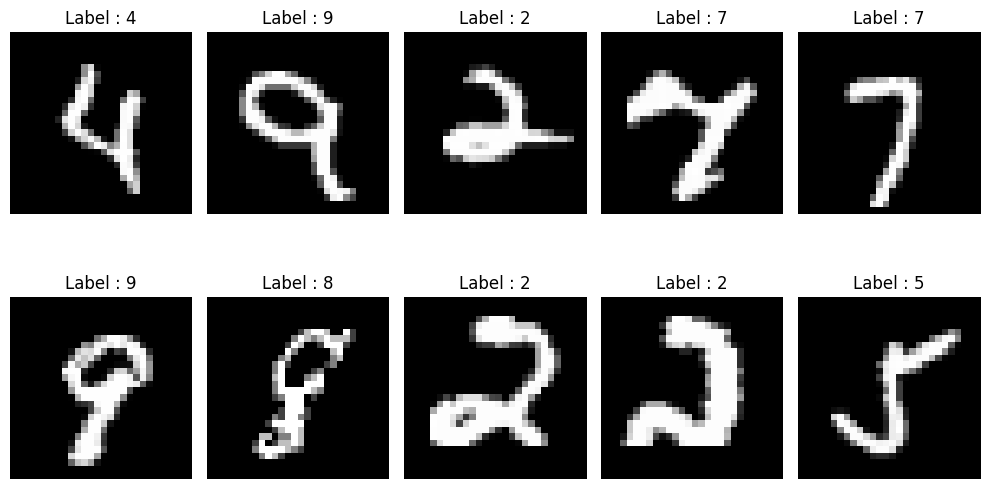

In [91]:
visualize_5n_images(n = 2)

### Data Distribution

In [9]:
from sklearn.manifold import TSNE

def data_distribution(n_samples): 
    X_subset = X[:n_samples]
    Y_subset = y[:n_samples] if len(y) else None

    X_subset = X_subset / 255.0

    # --- Apply t-SNE ---
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
    X_embedded = tsne.fit_transform(X_subset)

    # --- Plot the result ---
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=Y_subset, cmap='tab10', s=10, alpha=0.7)
    plt.colorbar(scatter, label='Digit label')
    plt.title("t-SNE visualization of real data distribution p_data(x)")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.show()

In [10]:
def generated_data_distribution(n_samples, x_fake): 

    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
    fake_embedded = tsne.fit_transform(x_fake)

    plt.figure(figsize=(7, 6))
    plt.scatter(fake_embedded[:, 0], fake_embedded[:, 1], color='blue', s=10, alpha=0.6)
    plt.title("t-SNE visualization of fake data distribution p_g(x)")
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.show()

### Define a Generator $G$ to visualize a Generated Data Distribution

In [11]:
import torch
import torch.nn as nn

In [12]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 256, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(x)

In [13]:
z_dim = 100
n_samples = 2000
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
G = Generator()

In [15]:
z = torch.randn(n_samples, z_dim, device=device)
x_fake = G(z).detach().numpy().reshape((n_samples, 784))

print(type(x_fake))
print(x_fake.shape)

<class 'numpy.ndarray'>
(2000, 784)


### Not trained

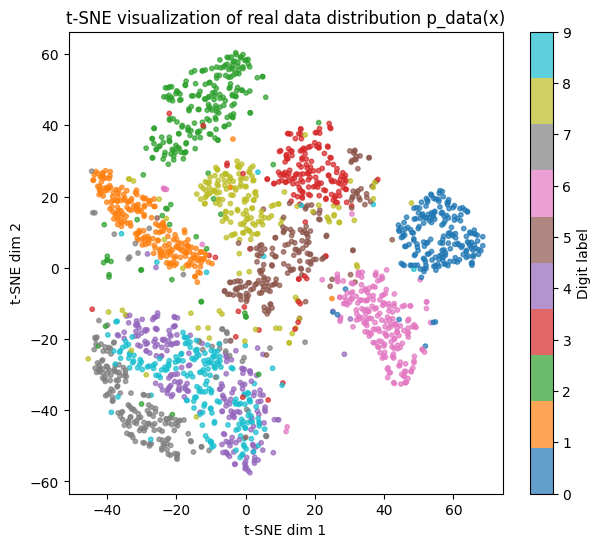

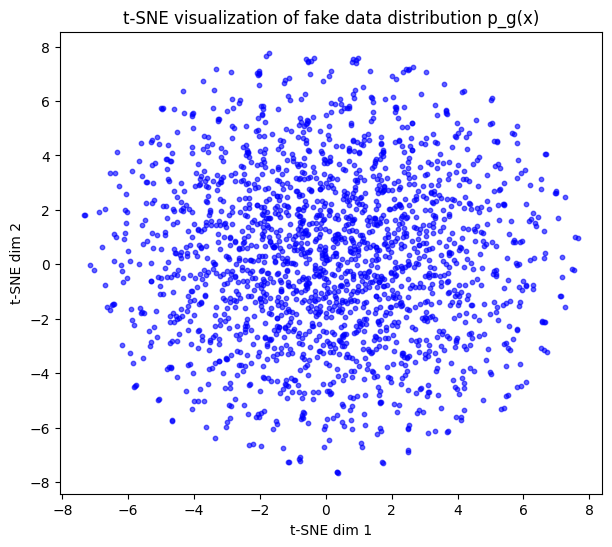

In [16]:
data_distribution(n_samples = n_samples)
generated_data_distribution(n_samples = n_samples, x_fake = x_fake)

### Trained

In [17]:
torch.serialization.add_safe_globals([__import__("__main__").Generator])
generator = torch.load("model_params/generator.pth", map_location=torch.device('cpu'), weights_only=False)
generator.eval()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)

### Fake data

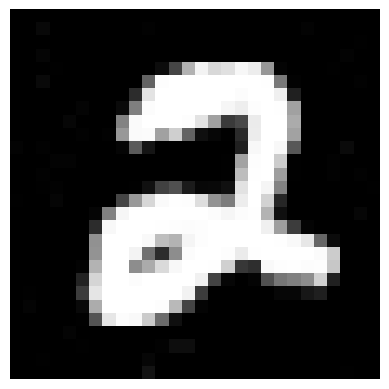

In [55]:
z = torch.randn(16, z_dim)  
with torch.no_grad():
    fake_images = generator(z)
grid = fake_images.view(-1, 1, 28, 28)  
plt.imshow(grid[0].squeeze(), cmap='gray')
plt.axis("off")
plt.show()


torch.Size([10, 28, 28])


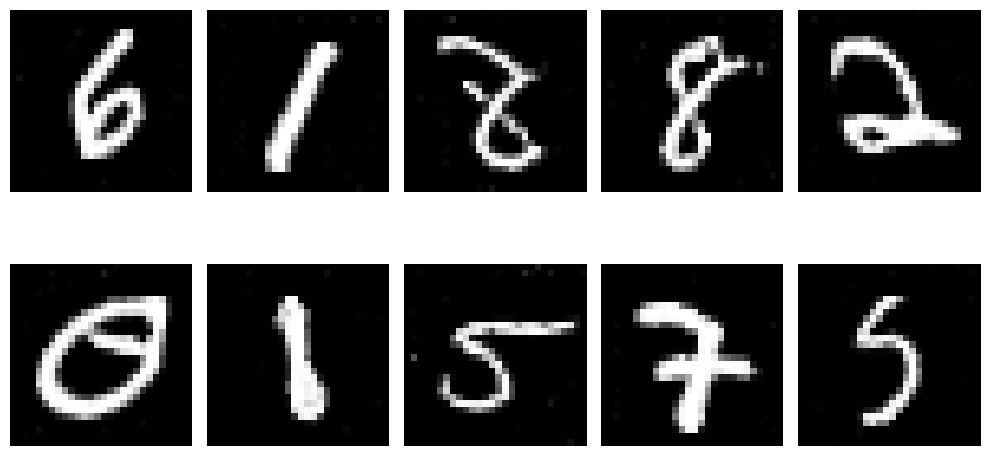

In [67]:
z = torch.randn(10, z_dim, device=device)

with torch.no_grad():
    fake_images = generator(z)
fake_images = fake_images.reshape((10, 28, 28))
print(fake_images.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 6))

for ax, img in zip(axes.flat, fake_images):
    ax.imshow(img, cmap='gray')    
    ax.axis('off')      

plt.tight_layout()
plt.show()

### Data distributions

In [19]:
z = torch.randn(n_samples, z_dim)  
with torch.no_grad():
    fake_images = generator(z)
    fake_images = fake_images.detach().numpy().reshape((n_samples, 784))

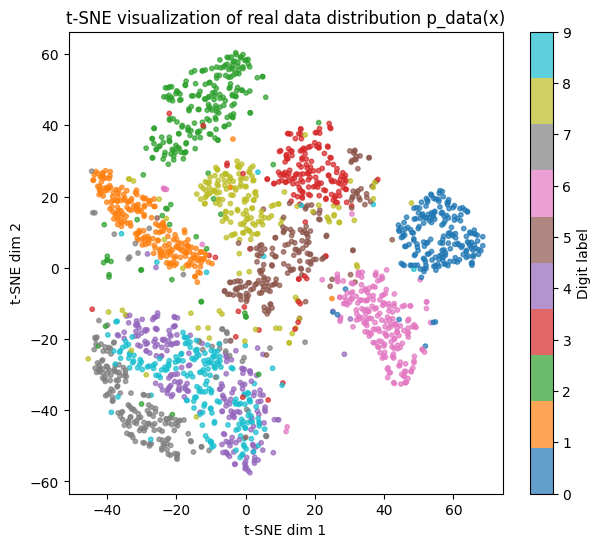

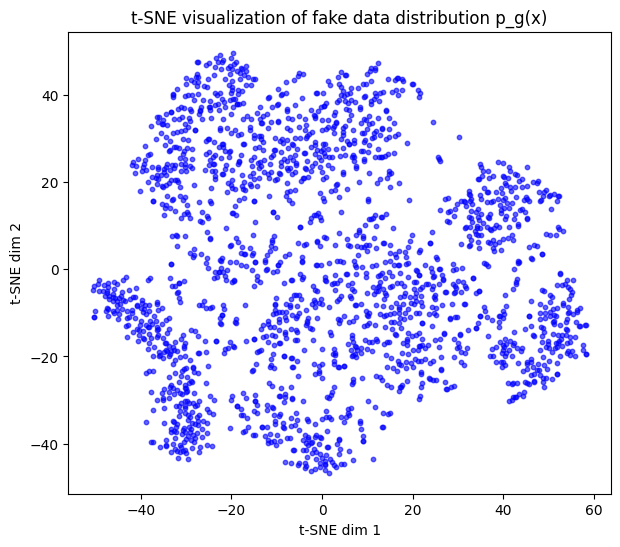

In [20]:
data_distribution(n_samples = n_samples)
generated_data_distribution(n_samples = n_samples, x_fake = fake_images)